2.1理论题

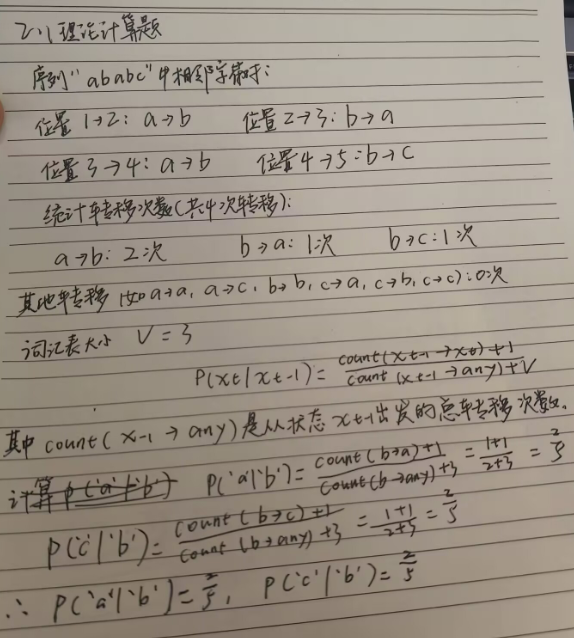

2.2编程题

In [1]:
import re
from collections import Counter

def preprocess_text(text, n):
    """
    文本预处理函数
    
    Args:
        text: 输入文本字符串
        n: 滑动窗口大小
    
    Returns:
        vocab: 词汇表字典 {词: ID}
        features: 特征序列列表，每个特征为长度为n的词列表
        labels: 标签列表
    """
    # 1. 转换为小写，去除标点符号（保留字母和空格）
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # 只保留字母和空格
    
    # 2. 按空格分词
    words = text.split()
    
    # 3. 构建词汇表（按出现频率排序）
    word_counts = Counter(words)
    sorted_vocab = sorted(word_counts.items(), key=lambda x: (-x[1], x[0]))
    vocab = {word: idx for idx, (word, _) in enumerate(sorted_vocab)}
    
    # 4. 生成特征序列和标签
    features = []
    labels = []
    for i in range(len(words) - n):
        features.append(words[i:i+n])
        labels.append(words[i+n])
    
    return vocab, features, labels

# 测试
if __name__ == "__main__":
    text = "The time machine"
    vocab, features, labels = preprocess_text(text, 2)
    
    print("词汇表:", vocab)
    print("特征:", features)
    print("标签:", labels)
    
    # 输出：
    # 词汇表: {'time': 0, 'machine': 1, 'the': 2}
    # 特征: [['the', 'time'], ['time', 'machine']]
    # 标签: ['machine']

词汇表: {'machine': 0, 'the': 1, 'time': 2}
特征: [['the', 'time']]
标签: ['machine']


3.1理论题

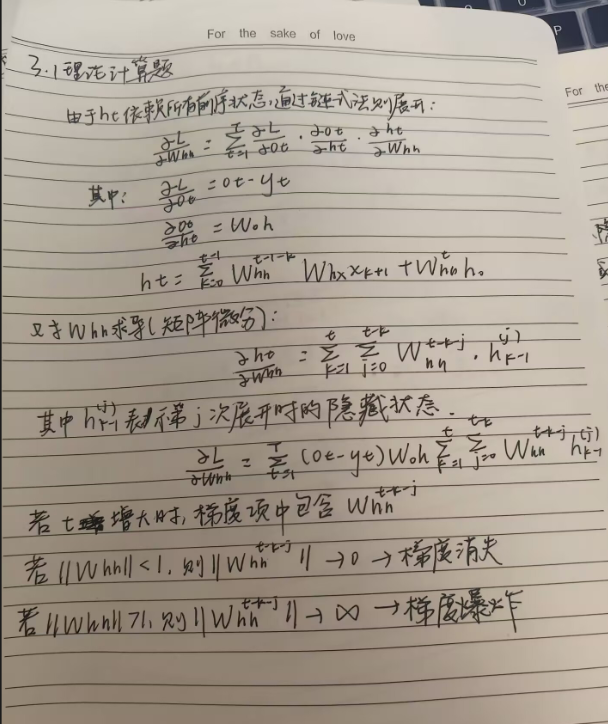

3.2编程题

In [2]:
import numpy as np

def rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """
    RNN单元前向传播
    
    Args:
        x_t: (batch_size, input_size)
        h_prev: (batch_size, hidden_size)
        W_hx: (input_size, hidden_size)
        W_hh: (hidden_size, hidden_size)
        b_h: (hidden_size,)
    
    Returns:
        h_t: (batch_size, hidden_size)
        cache: 缓存用于反向传播
    """
    # 计算输入门
    a_t = np.dot(x_t, W_hx) + np.dot(h_prev, W_hh) + b_h
    h_t = np.tanh(a_t)
    
    cache = (x_t, h_prev, h_t, a_t, W_hx, W_hh, b_h)
    return h_t, cache

def rnn_cell_backward(dh_next, cache):
    """
    RNN单元反向传播
    
    Args:
        dh_next: (batch_size, hidden_size) 损失对h_t的梯度
        cache: 前向传播缓存
    
    Returns:
        dx_t: (batch_size, input_size)
        dh_prev: (batch_size, hidden_size)
        dW_hx: (input_size, hidden_size)
        dW_hh: (hidden_size, hidden_size)
        db_h: (hidden_size,)
    """
    x_t, h_prev, h_t, a_t, W_hx, W_hh, b_h = cache
    
    batch_size, hidden_size = h_prev.shape
    
    # tanh的导数: dtanh = 1 - tanh^2
    da_t = dh_next * (1 - h_t ** 2)
    
    # 计算梯度
    dx_t = np.dot(da_t, W_hx.T)
    dh_prev = np.dot(da_t, W_hh.T)
    dW_hx = np.dot(x_t.T, da_t)
    dW_hh = np.dot(h_prev.T, da_t)
    db_h = np.sum(da_t, axis=0)
    
    return dx_t, dh_prev, dW_hx, dW_hh, db_h

# 测试
if __name__ == "__main__":
    batch_size, input_size, hidden_size = 2, 4, 3
    x_t = np.random.randn(batch_size, input_size)
    h_prev = np.random.randn(batch_size, hidden_size)
    W_hx = np.random.randn(input_size, hidden_size)
    W_hh = np.random.randn(hidden_size, hidden_size)
    b_h = np.random.randn(hidden_size)
    
    h_t, cache = rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h)
    print("h_t shape:", h_t.shape)  # (2, 3)
    
    dh_next = np.random.randn(batch_size, hidden_size)
    dx_t, dh_prev, dW_hx, dW_hh, db_h = rnn_cell_backward(dh_next, cache)
    
    print("dx_t shape:", dx_t.shape)       # (2, 4)
    print("dh_prev shape:", dh_prev.shape) # (2, 3)
    print("dW_hx shape:", dW_hx.shape)     # (4, 3)
    print("dW_hh shape:", dW_hh.shape)     # (3, 3)
    print("db_h shape:", db_h.shape)       # (3,)

h_t shape: (2, 3)
dx_t shape: (2, 4)
dh_prev shape: (2, 3)
dW_hx shape: (4, 3)
dW_hh shape: (3, 3)
db_h shape: (3,)


4.1理论题

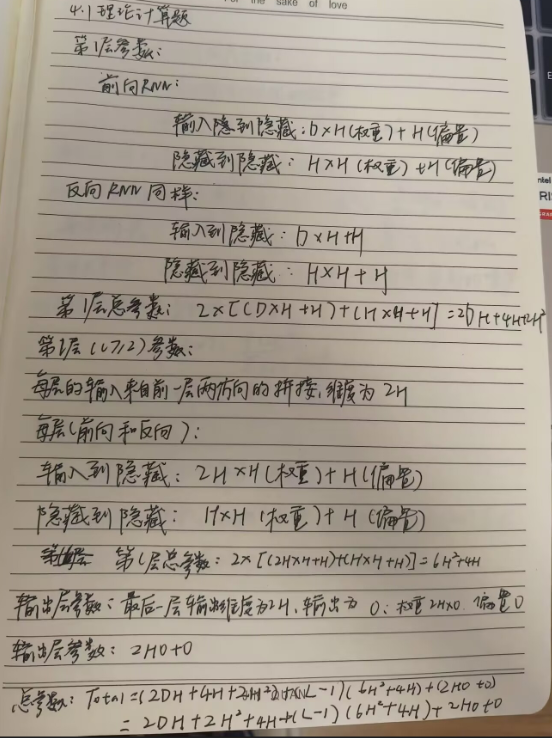

4.2编程题

In [3]:
import torch
import torch.nn as nn

class BidirectionalRNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 使用PyTorch的RNN实现双向
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=False  # 保持 (seq_len, batch, feature)
        )
    
    def forward(self, X):
        """
        Args:
            X: (seq_len, batch, input_dim)
        
        Returns:
            all_states: (seq_len, batch, 2*hidden_dim) 每个时间步拼接后的隐藏状态
            final_state: (batch, 2*hidden_dim) 最终时间步的拼接隐藏状态
        """
        # RNN前向传播
        output, h_n = self.rnn(X)
        # output: (seq_len, batch, 2*hidden_dim)
        # h_n: (2*num_layers, batch, hidden_dim)
        
        # 最终时间步的状态：取最后一层的前向和后向
        # 前向：第 num_layers-1 层，后向：第 2*num_layers-1 层
        forward_last = h_n[-2, :, :]   # (batch, hidden_dim)
        backward_last = h_n[-1, :, :]  # (batch, hidden_dim)
        final_state = torch.cat([forward_last, backward_last], dim=1)  # (batch, 2*hidden_dim)
        
        return output, final_state

# 测试
if __name__ == "__main__":
    seq_len, batch, input_dim, hidden_dim = 5, 3, 4, 8
    X = torch.randn(seq_len, batch, input_dim)
    
    encoder = BidirectionalRNNEncoder(input_dim, hidden_dim)
    output, final_state = encoder(X)
    
    print("output shape:", output.shape)        # (5, 3, 16)
    print("final_state shape:", final_state.shape)  # (3, 16)

output shape: torch.Size([5, 3, 16])
final_state shape: torch.Size([3, 16])


5.1理论题

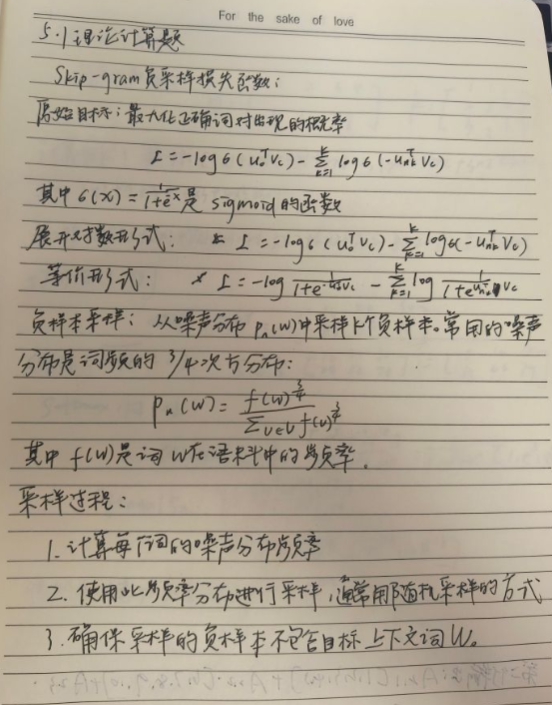

5.2编程题

In [4]:
import torch
import torch.nn.functional as F

def cbow_forward(context_indices, W_in, W_out):
    """
    CBOW模型前向传播和损失计算
    
    Args:
        context_indices: (batch_size, context_size) 上下文词索引
        W_in: (V, d) 输入权重矩阵
        W_out: (d, V) 输出权重矩阵
        target: (batch_size,) 目标中心词索引（在外部提供）
    
    Returns:
        loss: 交叉熵损失
        probs: (batch_size, V) 输出概率分布
    """
    batch_size, context_size = context_indices.shape
    
    # 1. 获取上下文词嵌入 (batch_size, context_size, d)
    embeddings = W_in[context_indices]  # (batch_size, context_size, d)
    
    # 2. 计算平均上下文向量 (batch_size, d)
    h = embeddings.mean(dim=1)  # (batch_size, d)
    
    # 3. 计算输出层 (batch_size, V)
    scores = torch.mm(h, W_out)  # (batch_size, V)
    probs = F.softmax(scores, dim=1)  # (batch_size, V)
    
    return probs, h

def cbow_loss(probs, target):
    """
    计算交叉熵损失
    
    Args:
        probs: (batch_size, V) 概率分布
        target: (batch_size,) 目标索引
    
    Returns:
        loss: 标量损失值
    """
    loss = F.cross_entropy(torch.log(probs + 1e-8), target)
    return loss

# 完整CBOW类
class CBOWModel:
    def __init__(self, vocab_size, embedding_dim):
        self.V = vocab_size
        self.d = embedding_dim
        # 初始化权重
        self.W_in = torch.randn(vocab_size, embedding_dim) * 0.01
        self.W_out = torch.randn(embedding_dim, vocab_size) * 0.01
    
    def forward(self, context_indices, target):
        """
        完整前向传播
        
        Args:
            context_indices: (batch_size, context_size)
            target: (batch_size,)
        
        Returns:
            loss: 交叉熵损失
            probs: (batch_size, V)
        """
        probs, h = cbow_forward(context_indices, self.W_in, self.W_out)
        loss = cbow_loss(probs, target)
        return loss, probs

# 测试
if __name__ == "__main__":
    V, d, batch_size, context_size = 10, 4, 2, 3
    
    # 创建模型
    model = CBOWModel(V, d)
    
    # 生成测试数据
    context_indices = torch.randint(0, V, (batch_size, context_size))
    target = torch.randint(0, V, (batch_size,))
    
    # 前向传播
    loss, probs = model.forward(context_indices, target)
    
    print("Loss:", loss.item())
    print("Probability shape:", probs.shape)  # (2, 10)
    print("Probability sum (each row):", probs.sum(dim=1))  # [1, 1]

Loss: 2.3026556968688965
Probability shape: torch.Size([2, 10])
Probability sum (each row): tensor([1., 1.])


6.1理论题

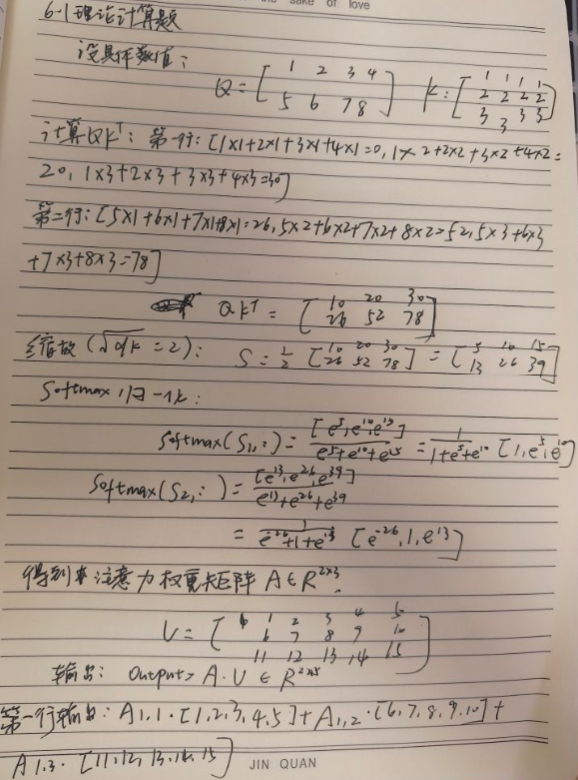
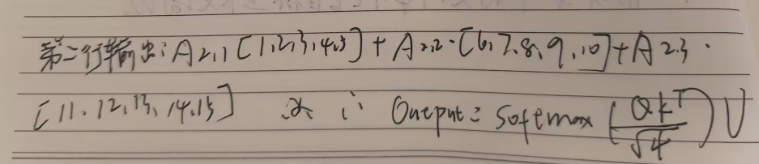

6.2编程题

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = d_model // num_heads
        
        # 线性投影层
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, X):
        """
        Args:
            X: (seq_len, batch, d_model)
        
        Returns:
            output: (seq_len, batch, d_model)
        """
        seq_len, batch, _ = X.shape
        
        # 1. 线性投影并分头
        Q = self.W_q(X)  # (seq_len, batch, d_model)
        K = self.W_k(X)
        V = self.W_v(X)
        
        # 2. 重塑为多头格式
        # (seq_len, batch, num_heads, d_k) -> (batch, num_heads, seq_len, d_k)
        Q = Q.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)
        K = K.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)
        V = V.view(seq_len, batch, self.num_heads, self.d_v).transpose(0, 1).transpose(1, 2)
        
        # 3. 计算缩放点积注意力
        # 得分: (batch, num_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.d_k, dtype=torch.float32))
        attn_weights = F.softmax(scores, dim=-1)
        
        # 4. 加权求和: (batch, num_heads, seq_len, d_v)
        attn_output = torch.matmul(attn_weights, V)
        
        # 5. 拼接所有头
        # (batch, seq_len, num_heads, d_v) -> (seq_len, batch, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(seq_len, batch, self.d_model)
        
        # 6. 最终线性层
        output = self.W_o(attn_output)
        
        return output

# 测试
if __name__ == "__main__":
    seq_len, batch, d_model = 5, 2, 4
    num_heads = 2
    
    X = torch.randn(seq_len, batch, d_model)
    mha = MultiHeadAttention(d_model, num_heads)
    output = mha(X)
    
    print("Input shape:", X.shape)        # (5, 2, 4)
    print("Output shape:", output.shape)  # (5, 2, 4)

Input shape: torch.Size([5, 2, 4])
Output shape: torch.Size([5, 2, 4])
